<div class="alert alert-block alert-info" style="margin-top: 20px">
<h1 align="center"><font size="5">BAN 130: Python Assignment - Titanic Data Exploration</font></h1>
</div>

**Student Name:** ____________________  
**Dataset:** Titanic dataset from GitHub  
**Source used in Python:** `https://raw.githubusercontent.com/vijita/data/main/titanic.csv`

In this assignment, I used the Titanic dataset from GitHub. Since the questions mention the **original 8-passenger sample**, I loaded the full dataset first and then selected the first 8 rows as the sample for analysis. The answers are written in simple student-style language.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Problem #1: Data Exploration & Filtering</h1>
</div>

In this problem, I loaded the Titanic dataset and checked the total number of passengers in the 8-passenger sample. I also counted how many passengers survived. After that, I filtered the data to show only female passengers who were in 3rd class.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside the notebook
%matplotlib inline

# Load Titanic data from GitHub
url = "https://raw.githubusercontent.com/vijita/data/main/titanic.csv"

try:
    titanic_full = pd.read_csv(url)
except Exception:
    # Backup sample in case the online link is not available while running the notebook
    data = {
        "PassengerId": [1, 2, 3, 4, 5, 6, 7, 8],
        "Survived": [0, 1, 1, 1, 0, 0, 0, 0],
        "Pclass": [3, 1, 3, 1, 3, 3, 1, 3],
        "Name": [
            "Braund, Mr. Owen Harris",
            "Cumings, Mrs. John Bradley (Florence Briggs Thayer)",
            "Heikkinen, Miss. Laina",
            "Futrelle, Mrs. Jacques Heath (Lily May Peel)",
            "Allen, Mr. William Henry",
            "Moran, Mr. James",
            "McCarthy, Mr. Timothy J",
            "Palsson, Master. Gosta Leonard"
        ],
        "Sex": ["male", "female", "female", "female", "male", "male", "male", "male"],
        "Age": [22, 38, 26, 35, 35, None, 54, 2],
        "SibSp": [1, 1, 0, 1, 0, 0, 0, 3],
        "Parch": [0, 0, 0, 0, 0, 0, 0, 1],
        "Ticket": ["A/5 21171", "PC 17599", "STON/O2. 3101282", "113803", "373450", "330877", "17463", "349909"],
        "Fare": [7.25, 71.2833, 7.925, 53.1, 8.05, 8.4583, 51.8625, 21.075],
        "Cabin": [None, "C85", None, "C123", None, None, "E46", None],
        "Embarked": ["S", "C", "S", "S", "S", "Q", "S", "S"]
    }
    titanic_full = pd.DataFrame(data)

# The assignment mentions an original 8-passenger sample, so I use the first 8 passengers.
df = titanic_full.head(8).copy()

print("First 8-passenger sample:")
display(df)

# Total passengers and survivors in the sample
total_passengers = len(df)
total_survived = df["Survived"].sum()

print("Total number of passengers in this sample:", total_passengers)
print("Number of passengers who survived:", total_survived)

# Female passengers in 3rd class
female_third_class = df[(df["Sex"] == "female") & (df["Pclass"] == 3)]

print("\nFemale passengers in 3rd class:")
display(female_third_class[["PassengerId", "Name", "Sex", "Pclass"]])

Matplotlib is building the font cache; this may take a moment.


First 8-passenger sample:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,None,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,None,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,None,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,None,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,None,S


Total number of passengers in this sample: 8
Number of passengers who survived: 3

Female passengers in 3rd class:


,PassengerId,Name,Sex,Pclass
2,3,"Heikkinen, Miss. Laina",female,3


**Problem 1 Answer:**  
There are **8 passengers** in this sample. Out of them, **3 passengers survived**. When I filtered the data for female passengers in 3rd class, I found **1 passenger**: **Heikkinen, Miss. Laina**.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Problem #2: Scaling Technique - Min-Max Scaling</h1>
</div>

In this problem, I found the minimum and maximum age values in the sample. Then I used the Min-Max scaling formula to scale the ages of Passenger 1 and Passenger 2.

The formula is:

\[
X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}
\]

In [2]:
# Find minimum and maximum age in the sample
min_age = df["Age"].min()
max_age = df["Age"].max()

print("Minimum Age:", min_age)
print("Maximum Age:", max_age)

# Ages for Passenger 1 and Passenger 2
passenger_1_age = df.loc[df["PassengerId"] == 1, "Age"].iloc[0]
passenger_2_age = df.loc[df["PassengerId"] == 2, "Age"].iloc[0]

# Min-Max scaling calculation
passenger_1_scaled = (passenger_1_age - min_age) / (max_age - min_age)
passenger_2_scaled = (passenger_2_age - min_age) / (max_age - min_age)

print("Passenger 1 Age:", passenger_1_age)
print("Passenger 1 Min-Max Scaled Age:", round(passenger_1_scaled, 3))

print("Passenger 2 Age:", passenger_2_age)
print("Passenger 2 Min-Max Scaled Age:", round(passenger_2_scaled, 3))

Minimum Age: 2.0
Maximum Age: 54.0
Passenger 1 Age: 22.0
Passenger 1 Min-Max Scaled Age: 0.385
Passenger 2 Age: 38.0
Passenger 2 Min-Max Scaled Age: 0.692


**Problem 2 Answer:**  
The minimum age in this sample is **2 years**, and the maximum age is **54 years**. Using Min-Max scaling, Passenger 1 with age 22 has a scaled value of **0.385**. Passenger 2 with age 38 has a scaled value of **0.692**.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Problem #3: Grouping and Aggregation</h1>
</div>

In this problem, I grouped the data by gender. Then I calculated the total count of passengers, mean age, and survival rate for each gender.

In [3]:
# Group by Sex and calculate count, mean age, and survival rate
gender_group = df.groupby("Sex").agg(
    total_count=("PassengerId", "count"),
    mean_age=("Age", "mean"),
    survival_rate=("Survived", "mean")
).reset_index()

# Round values for cleaner display
gender_group["mean_age"] = gender_group["mean_age"].round(2)
gender_group["survival_rate"] = gender_group["survival_rate"].round(2)

display(gender_group)

# Find gender with higher survival rate
higher_survival_gender = gender_group.loc[gender_group["survival_rate"].idxmax(), "Sex"]
print("Gender with higher survival rate:", higher_survival_gender)

,Sex,total_count,mean_age,survival_rate
0,female,3,33.00,1.0
1,male,5,28.25,0.0


Gender with higher survival rate: female


**Problem 3 Answer:**  
In this sample, female passengers had the higher survival rate. The female survival rate is **1.00**, which means all female passengers in the sample survived. The male survival rate is **0.00**, which means none of the male passengers in the sample survived. The average age of female passengers is **33.00**, and the average age of male passengers is **28.25**.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Problem #4: Visualization</h1>
</div>

In this problem, I checked the relationship between passenger age and fare. I used a scatter plot to see the pattern visually. I also calculated the correlation between Age and Fare. Finally, I checked which fare looks like an outlier in the 8-passenger sample.

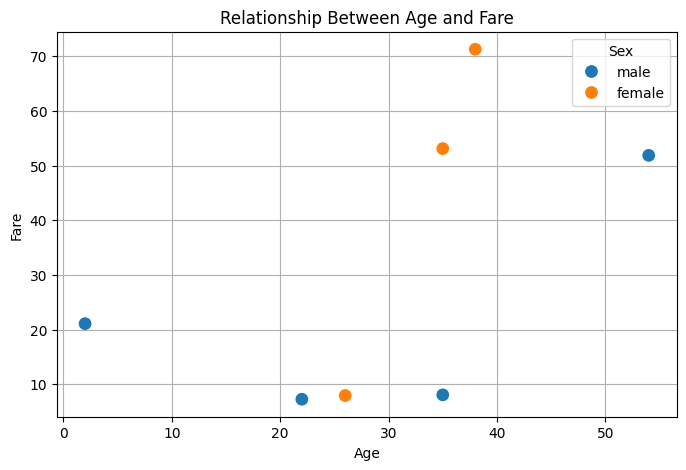

Correlation between Age and Fare: 0.535
Fare values from highest to lowest:


,PassengerId,Name,Fare
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",71.2833
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",53.1000
6,7,"McCarthy, Mr. Timothy J",51.8625
7,8,"Palsson, Master. Gosta Leonard",21.0750
5,6,"Moran, Mr. James",8.4583
4,5,"Allen, Mr. William Henry",8.0500
2,3,"Heikkinen, Miss. Laina",7.9250
0,1,"Braund, Mr. Owen Harris",7.2500


Passenger with fare that looks like an outlier:
Cumings, Mrs. John Bradley (Florence Briggs Thayer) with fare 71.2833


In [4]:
# Scatter plot between Age and Fare
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="Fare", hue="Sex", s=100)
plt.title("Relationship Between Age and Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.grid(True)
plt.show()

# Correlation between Age and Fare
age_fare_corr = df[["Age", "Fare"]].corr().loc["Age", "Fare"]
print("Correlation between Age and Fare:", round(age_fare_corr, 3))

# Check fare values to identify possible outlier
fare_values = df[["PassengerId", "Name", "Fare"]].sort_values(by="Fare", ascending=False)
print("Fare values from highest to lowest:")
display(fare_values)

# Identify passenger with the highest fare
outlier_passenger = fare_values.iloc[0]
print("Passenger with fare that looks like an outlier:")
print(outlier_passenger["Name"], "with fare", outlier_passenger["Fare"])

**Problem 4 Answer:**  
The correlation between **Age** and **Fare** is about **0.535**, which shows a moderate positive relationship in this small sample. This means that, in this sample, older passengers generally paid a higher fare, but the relationship is not perfect.

The fare that looks most like an outlier is **71.2833**, paid by **Cumings, Mrs. John Bradley (Florence Briggs Thayer)**. This fare is higher than the other fares in the 8-passenger sample.

## Final Conclusion

This assignment helped me practice basic data exploration, filtering, scaling, grouping, aggregation, and visualization in Python. From the 8-passenger Titanic sample, I found that 3 passengers survived. Female passengers had a higher survival rate than male passengers in this small sample. The Min-Max scaling technique changed age values into a 0 to 1 range, which makes comparison easier. The scatter plot and correlation showed a moderate positive relationship between age and fare, and Passenger 2 had the highest fare in the sample.